Replica de articulo https://www.quantconnect.com/research/18987/portfolio-construction-using-topological-data-analysis/p1 

# Librerías

In [25]:
import pandas as pd
import numpy as np
import random

import plotly
import requests
from bs4 import BeautifulSoup
import ruptures as rpt
import yfinance as yf

import plotly.graph_objects as go
import matplotlib.pyplot as plt

import kmapper as km
import subprocess
import sys
import networkx as nx
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat>=4.2.0"])
import sklearn.cluster

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


## 🎲 Fijar Semillas para Reproducibilidad

In [26]:
# =======================================================
# 🎲 FIJAR TODAS LAS SEMILLAS ALEATORIAS
# =======================================================
# Esto garantiza resultados idénticos en cada ejecución

SEED = 42  # Puedes cambiar este número si quieres otra "versión" del mapper

# Python built-in
import random
random.seed(SEED)

# NumPy
import numpy as np
np.random.seed(SEED)

# Si usas TensorFlow/PyTorch (opcional)
try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
except:
    pass

try:
    import torch
    torch.manual_seed(SEED)
except:
    pass

print("🎲 Semillas aleatorias fijadas:")
print(f"   SEED = {SEED}")
print("   ✅ Python random")
print("   ✅ NumPy")
print("   ✅ Todos los algoritmos usarán resultados reproducibles")
print("=" * 80)

🎲 Semillas aleatorias fijadas:
   SEED = 42
   ✅ Python random
   ✅ NumPy
   ✅ Todos los algoritmos usarán resultados reproducibles


# Datos

## Sacar tickers

In [27]:
# =======================================================
# 📊 OBTENCIÓN DE TICKERS DEL S&P 500
# =======================================================

import os

# Verificar si el archivo ya existe
tickers_filename = 'tickers_S&P.csv'

if os.path.exists(tickers_filename):
    # ✅ ARCHIVO EXISTE - Cargar tickers existentes
    print("✅ Archivo 'tickers_S&P.csv' encontrado")
    print("📂 Cargando tickers desde archivo guardado...")
    print("=" * 80)
    
    try:
        tickers_df = pd.read_csv(tickers_filename)
        
        # Extraer lista de tickers
        if 'Symbol' in tickers_df.columns:
            tickers = tickers_df['Symbol'].tolist()
            print(f"✅ Tickers cargados exitosamente: {len(tickers)}")
            print(f"   Primeros 10 tickers: {tickers[:10]}")
        else:
            print(f"❌ Columna 'Symbol' no encontrada. Columnas disponibles: {tickers_df.columns.tolist()}")
            raise ValueError("Formato de archivo incorrecto")
        
        # Extraer pesos si existen
        if 'Weight' in tickers_df.columns:
            weights = tickers_df['Weight'].tolist()
            #print(f"   Pesos disponibles: {len(weights)}")
            print(f"   Primeros 10 pesos: {weights[:10]}")
        
        
        
    except Exception as e:
        print(f"❌ Error al cargar el archivo: {e}")
        print(f"⚠️  Se procederá a descargar los tickers nuevamente...")
        # Si hay error, forzar descarga
        os.remove(tickers_filename) if os.path.exists(tickers_filename) else None
        tickers_df = None

else:
    # ❌ ARCHIVO NO EXISTE - Descargar tickers del S&P 500
    print("⚠️  Archivo 'tickers_S&P.csv' no encontrado")
    print("🔍 Descargando lista de tickers del S&P 500 desde Slickcharts...")
    print("=" * 80)
    
    # URL de la lista del S&P 500
    url = "https://www.slickcharts.com/sp500"
    
    # Hacer la petición con headers para evitar bloqueos
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    response = requests.get(url, headers=headers)
    response.raise_for_status()  # Raise exception for bad status codes
    
    # Parsear el HTML
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Encontrar la tabla
    table = soup.find('table')
    
    if table:
        # Leer la tabla con pandas
        df = pd.read_html(str(table))[0]
        
        # Extraer los tickers
        if 'Symbol' in df.columns:
            tickers = df['Symbol'].tolist()
            print(f"✅ Descargados {len(tickers)} tickers")
            print(f"   Primeros 10 tickers: {tickers[:10]}")
        else:
            print(f"❌ Columna 'Symbol' no encontrada")
            print(f"   Columnas disponibles: {df.columns.tolist()}")
            tickers = []
        
        # Extraer los pesos
        if 'Weight' in df.columns:
            weights = df['Weight'].tolist()
            print(f"   Descargados {len(weights)} pesos")
            print(f"   Primeros 10 pesos: {weights[:10]}")
        else:
            print(f"⚠️  Columna 'Weight' no encontrada")
            print(f"   Columnas disponibles: {df.columns.tolist()}")
        
        # Guardar en CSV para uso posterior
        tickers_df = df
        tickers_df.to_csv(tickers_filename, index=False)
        print(f"\n💾 Lista de tickers guardada en '{tickers_filename}'")
        
    else:
        print("❌ No se encontró tabla en la página")
        tickers = []

# En la lista de ticker, reemplazar los "." por "-"
tickers = [ticker.replace('.', '-') for ticker in tickers]

print("=" * 80)

✅ Archivo 'tickers_S&P.csv' encontrado
📂 Cargando tickers desde archivo guardado...
✅ Tickers cargados exitosamente: 503
   Primeros 10 tickers: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK.B']
   Primeros 10 pesos: ['7.13%', '6.68%', '5.87%', '3.99%', '3.26%', '3.06%', '3.03%', '2.60%', '2.31%', '1.80%']


## Historicos

In [28]:
#START_DATE='2015-01-01'
START_DATE='2022-01-01'
END_DATE='2025-11-01'
AN_DATE='2024-01-01'

In [29]:
# =======================================================
# 📊 DESCARGA DE PRECIOS HISTÓRICOS - S&P 500 TICKERS
# =======================================================

historicos_filename = f'historicos_SP500_{START_DATE}_to_{END_DATE}.csv'

if os.path.exists(historicos_filename):
    print("✅ Archivo de históricos encontrado")
    print(f"📂 Cargando datos desde '{historicos_filename}'...")
    all_tickers_data = pd.read_csv(historicos_filename, index_col=0, parse_dates=True)
    all_tickers_data.index = pd.to_datetime(all_tickers_data.index)
    print(f"   Datos cargados: {all_tickers_data.shape}")
else:
    print(f"⚠️  Archivo '{historicos_filename}' no encontrado")
    print(f"🔍 Descargando datos para {len(tickers)} tickers...")
    all_tickers_data_raw = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
    all_tickers_data = all_tickers_data_raw.dropna(axis=1)  # Eliminar columnas con datos faltantes
    all_tickers_data.to_csv(historicos_filename)
    print(f"💾 Datos guardados en '{historicos_filename}'")

# Dividir en dos períodos
tickers_data = all_tickers_data.loc[START_DATE:AN_DATE]  # Análisis
validation_data = all_tickers_data.loc[AN_DATE:END_DATE]  # Validación

# Diagnóstico
tickers_descargados = set(all_tickers_data.columns)
tickers_faltantes = set(tickers) - tickers_descargados

print(f"\n✅ Resumen:")
print(f"   📊 Total: {all_tickers_data.shape}")
print(f"   📊 Análisis: {tickers_data.shape} ({START_DATE} a {AN_DATE})")
print(f"   📊 Validación: {validation_data.shape} ({AN_DATE} a {END_DATE})")
print(f"   ✅ Completos: {len(tickers_descargados)}")
print(f"   ❌ Faltantes: {len(tickers_faltantes)}")
if tickers_faltantes:
    print(f"      {', '.join(sorted(list(tickers_faltantes))[:20])}{'...' if len(tickers_faltantes) > 20 else ''}")
print("=" * 80)

✅ Archivo de históricos encontrado
📂 Cargando datos desde 'historicos_SP500_2022-01-01_to_2025-11-01.csv'...
   Datos cargados: (962, 495)

✅ Resumen:
   📊 Total: (962, 495)
   📊 Análisis: (501, 495) (2022-01-01 a 2024-01-01)
   📊 Validación: (461, 495) (2024-01-01 a 2025-11-01)
   ✅ Completos: 495
   ❌ Faltantes: 8
      CEG, GEHC, GEV, KVUE, Q, SOLS, SOLV, VLTO


In [30]:
# =======================================================
# 📊 DESCARGA DE PRECIOS HISTÓRICOS - SPY (BENCHMARK)
# =======================================================

spy_filename = f'historicos_SPY_{START_DATE}_{END_DATE}.csv'

if os.path.exists(spy_filename):
    print(f"✅ Archivo '{spy_filename}' encontrado")
    SPY = pd.read_csv(spy_filename, index_col=0, parse_dates=True)
    SPY.index = pd.to_datetime(SPY.index)
else:
    print(f"⚠️  Archivo '{spy_filename}' no encontrado")
    print("🔍 Descargando datos de SPY...")
    SPY_data = yf.download('SPY', start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
    SPY = SPY_data.to_frame(name='SPY') if isinstance(SPY_data, pd.Series) else SPY_data
    if 'SPY' not in SPY.columns:
        SPY.columns = ['SPY']
    SPY.to_csv(spy_filename)
    print(f"💾 Datos guardados en '{spy_filename}'")

# Dividir en períodos

SPY_analysis = SPY.loc[START_DATE:AN_DATE]
print("=" * 80)

SPY_validation = SPY.loc[AN_DATE:END_DATE]
print(f"   📊 Validación: {SPY_validation.shape}")

print(f"   📊 Análisis: {SPY_analysis.shape}")
print(f"✅ SPY listo: {SPY.shape}")

✅ Archivo 'historicos_SPY_2022-01-01_2025-11-01.csv' encontrado
   📊 Validación: (461, 1)
   📊 Análisis: (501, 1)
✅ SPY listo: (962, 1)


## Info financiera

In [31]:
from datetime import timedelta
import pandas as pd

def marketcap_en_fecha(ticker, fecha):
    # Convert string to datetime if needed
    if isinstance(fecha, str):
        fecha = pd.to_datetime(fecha)
    
    t = yf.Ticker(ticker)
    
    # Use a wider date range to ensure data availability
    fecha_inicio = fecha - timedelta(days=7)  # Look back 7 days
    
    # Get historical data
    history = t.history(start=fecha_inicio, end=fecha)
    shares = t.get_shares_full(start=fecha_inicio, end=fecha)
    
    # Validate data exists
    if history.empty or 'Close' not in history.columns:
        raise ValueError(f"No price data for {ticker} around {fecha}")
    if shares.empty:
        raise ValueError(f"No shares data for {ticker} around {fecha}")
    
    # Get the closest available data to the target date
    price = history["Close"].iloc[-1]  # Most recent price
    shares_count = shares.iloc[-1]     # Most recent share count
    
    return price * shares_count

# Example usage
marketcap_en_fecha("AVGO", AN_DATE)

51197752848.026855

In [32]:
# =======================================================
# 📊 RECOPILACIÓN DE INFORMACIÓN FUNDAMENTAL DE TICKERS
# =======================================================

import os

# Verificar si el archivo ya existe
csv_filename = 'sp500_ticker_info_database.csv'

if os.path.exists(csv_filename):
    # ✅ ARCHIVO EXISTE - Cargar datos existentes
    print("✅ Archivo 'sp500_ticker_info_database.csv' encontrado")
    print("📂 Cargando información desde archivo guardado...")
    print("=" * 80)
    
    try:
        ticker_info_df = pd.read_csv(csv_filename, index_col=0)
        
        # Convertir DataFrame a diccionario para ticker_info_db
        ticker_info_db = ticker_info_df.to_dict('index')
        
        print(f"✅ Datos cargados exitosamente")
        print(f"   📊 Total de tickers: {len(ticker_info_df)}")
        print(f"   📋 Columnas: {len(ticker_info_df.columns)}")
        print(f"\n💡 Para actualizar los datos, elimina el archivo '{csv_filename}' y vuelve a ejecutar esta celda")
        
    except Exception as e:
        print(f"❌ Error al cargar el archivo: {e}")
        print(f"⚠️  Se procederá a descargar los datos nuevamente...")
        # Si hay error, forzar descarga
        os.remove(csv_filename) if os.path.exists(csv_filename) else None
        ticker_info_df = None

else:
    # ❌ ARCHIVO NO EXISTE - Descargar información
    print("⚠️  Archivo 'sp500_ticker_info_database.csv' no encontrado")
    print("🔍 Descargando información detallada de todos los tickers del S&P 500...")
    print("⏱️  Esto puede tardar varios minutos...")
    print("=" * 80)
    
    ticker_info_db = {}
    failed_tickers = []
    error_details = {}  # Guardar detalles de errores
    
    for idx, ticker in enumerate(tickers, 1):
        try:
            # Mostrar progreso cada 50 tickers
            if idx % 50 == 0 or idx == 1:
                print(f"   Procesando ticker {idx}/{len(tickers)}: {ticker}")
            
            # Paso 1: Obtener info básica
            stock = yf.Ticker(ticker)
            info = stock.info
            
            # Paso 2: Intentar obtener market cap histórico
            try:
                mc = marketcap_en_fecha(ticker, AN_DATE)
            except Exception as mc_error:
                # Si falla market cap histórico, usar el actual o None
                mc = info.get('marketCap', None)
                if idx % 50 == 0:  # Solo mostrar para algunos
                    print(f"      ⚠️  {ticker}: usando marketCap actual (error histórico: {str(mc_error)[:50]})")
            
            # Extraer información relevante
            ticker_info_db[ticker] = {
                # Información básica
                'sector': info.get('sector', 'Unknown'),
                'industry': info.get('industry', 'Unknown'),
                'market_cap': mc,
                'country': info.get('country', 'Unknown'),
                'full_name': info.get('longName', ticker),
                
                # Crecimiento
                'revenue_growth': info.get('revenueGrowth', None),
                'earnings_growth': info.get('earningsGrowth', None),
                'earnings_quarterly_growth': info.get('earningsQuarterlyGrowth', None),
                
                # Riesgo y volatilidad
                'beta': info.get('beta', None),
                '52week_high': info.get('fiftyTwoWeekHigh', None),
                '52week_low': info.get('fiftyTwoWeekLow', None),
                '52week_change': info.get('52WeekChange', None),

                # Analistas y recomendaciones
                'recommendation': info.get('recommendationKey', 'Unknown'),
                'recommendation_mean': info.get('recommendationMean', None),
                'target_mean_price': info.get('targetMeanPrice', None),
                'target_high_price': info.get('targetHighPrice', None),
                'target_low_price': info.get('targetLowPrice', None)
            }
            
        except Exception as e:
            error_type = type(e).__name__
            error_msg = str(e)
            
            failed_tickers.append(ticker)
            error_details[ticker] = f"{error_type}: {error_msg[:100]}"
            
            # Mostrar errores específicos
            if idx % 50 == 0 or len(failed_tickers) <= 5:
                print(f"      ❌ {ticker}: {error_type} - {error_msg[:80]}")
            
            ticker_info_db[ticker] = {
                'sector': 'Unknown',
                'industry': 'Unknown',
                'error': error_msg,
                'market_cap': None
            }
    
    # sacar solo marketcap válidos
    valid_mcaps = [d['market_cap'] for d in ticker_info_db.values() if d['market_cap'] is not None]

    
    mean_mc = sum(valid_mcaps) / len(valid_mcaps)
   

    # rellenar los None con el promedio
    for t in ticker_info_db:
        if ticker_info_db[t]['market_cap'] is None:
            ticker_info_db[t]['market_cap'] = mean_mc





    print(f"\n{'='*80}")
    print(f"📊 RESUMEN DE DESCARGA:")
    print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
    if failed_tickers:
        print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")
    
    # Crear DataFrame para análisis fácil
    ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')
    
    print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")
    
    # Guardar en CSV para uso posterior
    ticker_info_df.to_csv(csv_filename)
    print(f"   💾 Base de datos guardada en '{csv_filename}'")

# Mostrar primeras filas (común para ambos casos)
print(f"\n{'='*80}")
print("📋 Primeras filas de la base de datos:")
display(ticker_info_df)

✅ Archivo 'sp500_ticker_info_database.csv' encontrado
📂 Cargando información desde archivo guardado...
✅ Datos cargados exitosamente
   📊 Total de tickers: 503
   📋 Columnas: 5

💡 Para actualizar los datos, elimina el archivo 'sp500_ticker_info_database.csv' y vuelve a ejecutar esta celda

📋 Primeras filas de la base de datos:


,sector,industry,market_cap,country,full_name
NVDA,Technology,Semiconductors,1.222580e+11,United States,NVIDIA Corporation
AAPL,Technology,Consumer Electronics,2.966366e+12,United States,Apple Inc.
MSFT,Technology,Software - Infrastructure,2.758923e+12,United States,Microsoft Corporation
AMZN,Consumer Cyclical,Internet Retail,1.570148e+12,United States,"Amazon.com, Inc."
GOOGL,Communication Services,Internet Content & Information,1.743543e+12,United States,Alphabet Inc.
...,...,...,...,...,...
MTCH,Communication Services,Internet Content & Information,9.693210e+09,United States,"Match Group, Inc."
MOH,Healthcare,Healthcare Plans,7.290442e+09,United States,"Molina Healthcare, Inc."
SOLS,Basic Materials,Specialty Chemicals,6.864963e+09,United States,"Solstice Advanced Materials, Inc."
MHK,Consumer Cyclical,"Furnishings, Fixtures & Appliances",6.591108e+09,United States,"Mohawk Industries, Inc."


In [33]:
# sacar solo marketcap válidos (los que SI pudo obtener)
valid_mcaps = [v['market_cap'] for v in ticker_info_db.values() if v['market_cap'] is not None]

if len(valid_mcaps) > 0:
    mean_mc = sum(valid_mcaps) / len(valid_mcaps)
else:
    mean_mc = None

# rellenar los None con el promedio
for t in ticker_info_db:
    if ticker_info_db[t]['market_cap'] is None:
        ticker_info_db[t]['market_cap'] = mean_mc




print(f"\n{'='*80}")
print(f"📊 RESUMEN DE DESCARGA:")
print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
#if failed_tickers:
#    print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")

# Crear DataFrame para análisis fácil
ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')

print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")

# Guardar en CSV para uso posterior
ticker_info_df.to_csv(csv_filename)
print(f"   💾 Base de datos guardada en '{csv_filename}'")


📊 RESUMEN DE DESCARGA:
   ✅ Tickers procesados: 503

   📋 DataFrame de información creado: (503, 5)
   💾 Base de datos guardada en 'sp500_ticker_info_database.csv'


## Metricas

In [34]:
# Sacamos métricas de cada ticker

financial_metrics = {}
print("\n🔄 Calculando métricas financieras...")
for ticker in tickers_data.columns:
    try:
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # Métricas básicas
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        volatility = returns.std() * np.sqrt(252)  # Anualizada
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        
        # Métricas de riesgo
        max_drawdown = ((prices / prices.cummax()) - 1).min()
        var_95 = returns.quantile(0.05)  # Value at Risk 95%
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Métricas de tendencia
        returns_positive_ratio = (returns > 0).mean()
        trend_slope = np.polyfit(range(len(prices)), prices.values, 1)[0]
        
        financial_metrics[ticker] = {
            'total_return': total_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'var_95': var_95,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'positive_ratio': returns_positive_ratio,
            'trend_slope': trend_slope / prices.iloc[0]  # Normalizado
        }
    except Exception as e:
        print(f"❌ Error procesando {ticker}: {e}")

# Convertir a DataFrame
metrics_df = pd.DataFrame(financial_metrics).T

# Normalizar datos
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(metrics_df.fillna(0))# Datos normalizados que ya tenemos

# Preparar datos para KeplerMapper (usar métricas financieras)

ticker_names = metrics_df.index.tolist()


print(f"📊 Datos preparados: {metrics_scaled.shape[0]} tickers, {metrics_scaled.shape[1]} métricas")


🔄 Calculando métricas financieras...
📊 Datos preparados: 495 tickers, 9 métricas


# Modelo

In [35]:
# =======================================================
# 📊 PASO 1: SELECCIÓN DE UNIVERSO (TODOS LOS TICKERS S&P 500)
# =======================================================

print("="*80)
print("📊 SELECCIÓN DE UNIVERSO - TODOS LOS TICKERS S&P 500")
print("="*80)

# Obtener market caps de ticker_info_db
market_caps = {ticker: info['market_cap'] 
               for ticker, info in ticker_info_db.items() 
               if info['market_cap'] is not None}

# Ordenar por market cap (para estadísticas, pero USAR TODOS)
sorted_tickers = sorted(market_caps.items(), key=lambda x: x[1], reverse=True)

# Usar TODOS los tickers disponibles en tickers_data (no limitar a top 200)
available_tickers = [t for t in tickers_data.columns if t in market_caps]
universe_data = tickers_data[available_tickers].copy()

# Verificar si hay tickers en tickers_data que no están en ticker_info_db
tickers_without_info = set(tickers_data.columns) - set(market_caps.keys())
if len(tickers_without_info) > 0:
    print(f"⚠️  Tickers sin información de market cap: {len(tickers_without_info)}")
    print(f"   {', '.join(list(tickers_without_info)[:10])}{'...' if len(tickers_without_info) > 10 else ''}")

print(f"✅ Universo seleccionado: {len(available_tickers)} tickers (S&P 500 completo)")
print(f"📊 Datos del universo: {universe_data.shape}")
print(f"📅 Período: {universe_data.index[0].strftime('%Y-%m-%d')} a {universe_data.index[-1].strftime('%Y-%m-%d')}")
print(f"\n🔝 Top 10 tickers por market cap:")
for i, (ticker, mc) in enumerate(sorted_tickers[:10], 1):
    status = "✓" if ticker in available_tickers else "✗"
    print(f"   {status} {i:2d}. {ticker:5s}: ${mc/1e9:.2f}B")
print(f"\n📉 Bottom 10 tickers por market cap:")
for i, (ticker, mc) in enumerate(sorted_tickers[-10:], 1):
    status = "✓" if ticker in available_tickers else "✗"
    print(f"   {status} {i:2d}. {ticker:5s}: ${mc/1e9:.2f}B")
print("="*80)

📊 SELECCIÓN DE UNIVERSO - TODOS LOS TICKERS S&P 500
✅ Universo seleccionado: 495 tickers (S&P 500 completo)
📊 Datos del universo: (501, 495)
📅 Período: 2022-01-03 a 2023-12-29

🔝 Top 10 tickers por market cap:
   ✓  1. AAPL : $2966.37B
   ✓  2. MSFT : $2758.92B
   ✓  3. GOOGL: $1743.54B
   ✓  4. GOOG : $1743.39B
   ✓  5. AMZN : $1570.15B
   ✓  6. META : $904.05B
   ✓  7. TSLA : $789.90B
   ✓  8. BRK-B: $776.89B
   ✓  9. ORCL : $600.63B
   ✓ 10. LLY  : $545.71B

📉 Bottom 10 tickers por market cap:
   ✓  1. HAS  : $6.50B
   ✓  2. WSM  : $6.27B
   ✓  3. COO  : $4.69B
   ✓  4. TSCO : $4.52B
   ✓  5. DOC  : $4.35B
   ✓  6. TPL  : $3.93B
   ✓  7. ORLY : $3.75B
   ✓  8. DECK : $2.87B
   ✓  9. SMCI : $1.59B
   ✓ 10. CMG  : $1.26B


In [36]:
# =======================================================
# 📊 PASO 2: CALCULAR LOG-RETURNS
# =======================================================

print("\n" + "="*80)
print("📈 CÁLCULO DE LOG-RETURNS")
print("="*80)

# Calcular log-returns para el universo
log_returns = np.log(universe_data / universe_data.shift(1)).dropna()

print(f"✅ Log-returns calculados: {log_returns.shape}")
print(f"📊 Tickers: {log_returns.shape[1]}")
print(f"📅 Observaciones: {log_returns.shape[0]} días")

# Estadísticas básicas
print(f"\n📈 Estadísticas de log-returns:")
print(f"   Media: {log_returns.mean().mean():.6f}")
print(f"   Std Dev: {log_returns.std().mean():.6f}")
print(f"   Min: {log_returns.min().min():.6f}")
print(f"   Max: {log_returns.max().max():.6f}")
print("="*80)


📈 CÁLCULO DE LOG-RETURNS
✅ Log-returns calculados: (500, 495)
📊 Tickers: 495
📅 Observaciones: 500 días

📈 Estadísticas de log-returns:
   Media: 0.000034
   Std Dev: 0.020504
   Min: -0.610210
   Max: 0.335403


## Configuración

In [37]:
#Proyeccion PCA + UMAP

#PCA
n_components=0.9
random_state_pca=1

#UMAP
n_components=1
random_state_umap=1
n_jobs_umap=-1



# Clustering DBSCAN
metric='correlation'
n_jobs_clust=1
n_cubes=10
perc_overlap=0.3

## Keplermapper


🔬 TOPOLOGICAL DATA ANALYSIS - KEPLERMAPPER
📊 Datos de entrada para TDA: (495, 500)
   (Tickers x Días): 495 x 500
KeplerMapper(verbose=1)

🔧 Aplicando reducción de dimensionalidad...
   1️⃣ PCA (n_components=0.8) - Capturar 80% de varianza
   2️⃣ UMAP (n_components=1) - Proyección a 1D
..Composing projection pipeline of length 1:
	Projections: UMAP(n_components=1, random_state=1)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (495, 500)

..Projecting data using: 
	UMAP(n_components=1, random_state=1, verbose=1)

UMAP(n_components=1, n_jobs=1, random_state=1, verbose=1)
Wed Dec  3 21:54:20 2025 Construct fuzzy simplicial set
Wed Dec  3 21:54:20 2025 Finding Nearest Neighbors
Wed Dec  3 21:54:20 2025 Finished Nearest Neighbor Search
Wed Dec  3 21:54:20 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Dec  3 21:54:21 2025 Finished embedding

..Scaling with: MinMaxScaler()


✅ Proyección completada: (495, 1)
   Dimensión reducida: 1D


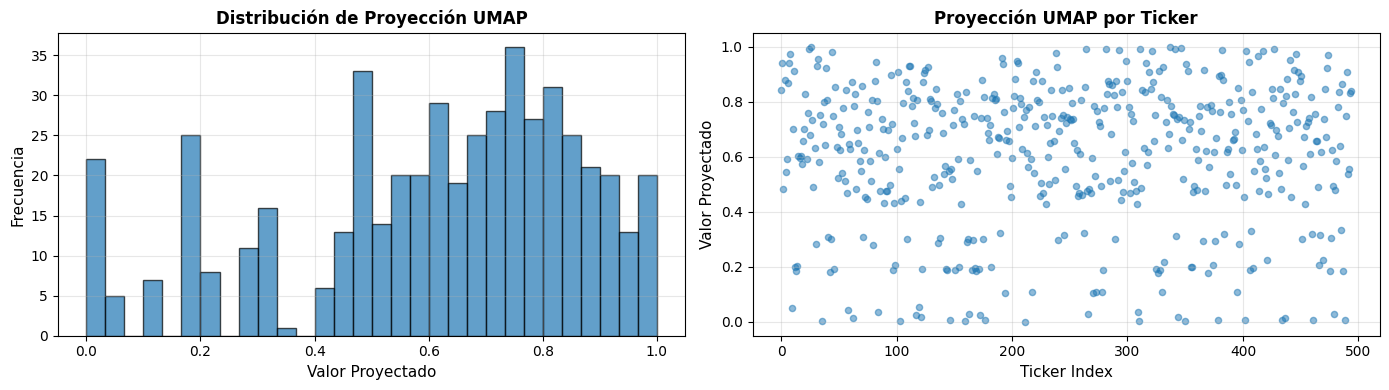

In [38]:
# =======================================================
# 📊 PASO 3: TOPOLOGICAL DATA ANALYSIS CON KEPLERMAPPER
# =======================================================

print("\n" + "="*80)
print("🔬 TOPOLOGICAL DATA ANALYSIS - KEPLERMAPPER")
print("="*80)

# Instalar umap-learn si no está disponible
try:
    import umap
except ImportError:
    print("📦 Instalando umap-learn...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn"])
    import umap

from umap import UMAP

# Transponer para que cada fila sea un ticker
log_returns_T = log_returns.T.values

print(f"📊 Datos de entrada para TDA: {log_returns_T.shape}")
print(f"   (Tickers x Días): {log_returns_T.shape[0]} x {log_returns_T.shape[1]}")

# Inicializar KeplerMapper
mapper = km.KeplerMapper(verbose=1)

print("\n🔧 Aplicando reducción de dimensionalidad...")
print("   1️⃣ PCA (n_components=0.8) - Capturar 80% de varianza")
print("   2️⃣ UMAP (n_components=1) - Proyección a 1D")

# Proyección con PCA + UMAP
projected_data = mapper.fit_transform(
    log_returns_T,
    projection=[
        #PCA(n_components=0.9, random_state=1),
        UMAP(n_components=1, random_state=1, n_jobs=-1)
    ]
)

print(f"\n✅ Proyección completada: {projected_data.shape}")
print(f"   Dimensión reducida: {projected_data.shape[1]}D")

# Visualizar distribución de la proyección
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(projected_data[:, 0], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Valor Proyectado', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Distribución de Proyección UMAP', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(projected_data)), projected_data[:, 0], alpha=0.5, s=20)
plt.xlabel('Ticker Index', fontsize=11)
plt.ylabel('Valor Proyectado', fontsize=11)
plt.title('Proyección UMAP por Ticker', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*80)

### Análisis mapper

In [39]:
# =======================================================
# 📊 ANÁLISIS DETALLADO DEL MAPPER
# =======================================================

print("\n" + "="*80)
print("📊 ANÁLISIS DETALLADO DEL MAPPER")
print("="*80)

# 1. Análisis de la proyección UMAP
print("\n1️⃣ ANÁLISIS DE LA PROYECCIÓN:")
print("-" * 80)

# projected_data es 2D con shape (n_samples, 1), aplanar para estadísticas
projection_values = projected_data.flatten()

projection_stats = {
    'min': projection_values.min(),
    'max': projection_values.max(),
    'mean': projection_values.mean(),
    'std': projection_values.std(),
    'range': projection_values.max() - projection_values.min()
}

print(f"📏 Estadísticas de la proyección UMAP:")
print(f"   Rango: [{projection_stats['min']:.3f}, {projection_stats['max']:.3f}]")
print(f"   Media: {projection_stats['mean']:.3f}")
print(f"   Desv. Est.: {projection_stats['std']:.3f}")
print(f"   Amplitud total: {projection_stats['range']:.3f}")

# Interpretación
if projection_stats['std'] > 2:
    print(f"\n💡 Interpretación: Alta dispersión → Tickers muy diferenciados")
# 2. Análisis de cobertura (Cover)
print(f"\n2️⃣ ANÁLISIS DE COBERTURA (COVER):")
print("-" * 80)

cube_size = projection_stats['range'] / n_cubes
overlap_size = cube_size * perc_overlap

print(f"📦 Parámetros del Cover:")
print(f"   Número de cubos: {n_cubes}")
print(f"   Solapamiento: {perc_overlap*100:.0f}%")
print(f"   Tamaño de cada cubo: {cube_size:.3f}")
print(f"   Tamaño del solapamiento: {overlap_size:.3f}")
print(f"   Solapamiento: {perc_overlap*100:.0f}%")
print(f"   Tamaño de cada cubo: {cube_size:.3f}")
print(f"   Tamaño del solapamiento: {overlap_size:.3f}")

# Calcular cuántos tickers por cubo (promedio)
avg_tickers_per_cube = len(available_tickers) / n_cubes
print(f"\n📊 Distribución esperada:")
print(f"   Tickers por cubo (promedio): {avg_tickers_per_cube:.1f}")
print(f"   Tickers en solapamiento: ~{avg_tickers_per_cube * perc_overlap:.1f}")

# 3. Análisis de estructura del grafo (después del clustering)
# Este análisis se hará en la siguiente celda después de crear el grafo

print("\n" + "="*80)


📊 ANÁLISIS DETALLADO DEL MAPPER

1️⃣ ANÁLISIS DE LA PROYECCIÓN:
--------------------------------------------------------------------------------
📏 Estadísticas de la proyección UMAP:
   Rango: [0.000, 1.000]
   Media: 0.609
   Desv. Est.: 0.259
   Amplitud total: 1.000

2️⃣ ANÁLISIS DE COBERTURA (COVER):
--------------------------------------------------------------------------------
📦 Parámetros del Cover:
   Número de cubos: 10
   Solapamiento: 30%
   Tamaño de cada cubo: 0.100
   Tamaño del solapamiento: 0.030
   Solapamiento: 30%
   Tamaño de cada cubo: 0.100
   Tamaño del solapamiento: 0.030

📊 Distribución esperada:
   Tickers por cubo (promedio): 49.5
   Tickers en solapamiento: ~14.8



### 📈 Visualización Interactiva de la Proyección

In [40]:
# =======================================================
# 📊 VISUALIZACIÓN MEJORADA DE LA PROYECCIÓN UMAP
# =======================================================

print("📊 GENERANDO VISUALIZACIÓN INTERACTIVA DE LA PROYECCIÓN")
print("="*80)

# Crear DataFrame para análisis
# Manejar tanto arrays 1D como 2D
projected_array = np.array(projected_data)

# Asegurar que sea al menos 1D
if projected_array.ndim == 0:
    umap_values = np.array([projected_array.item()] * len(available_tickers))
elif projected_array.ndim == 1:
    umap_values = projected_array
elif projected_array.ndim == 2:
    if projected_array.shape[1] == 1:
        umap_values = projected_array[:, 0]
    else:
        umap_values = projected_array[:, 0]
else:
    umap_values = projected_array.flatten()

projection_df = pd.DataFrame({
    'ticker': available_tickers,
    'umap_value': umap_values,
    'sector': [ticker_info_db.get(t, {}).get('sector', 'Unknown') for t in available_tickers],
    'market_cap': [ticker_info_db.get(t, {}).get('market_cap', 0) for t in available_tickers]
})

# Ordenar por valor UMAP
projection_df = projection_df.sort_values('umap_value')

# Crear visualización interactiva con Plotly
fig = go.Figure()

# Scatter plot con color por sector
sectors = projection_df['sector'].unique()
colors = px.colors.qualitative.Set3

for idx, sector in enumerate(sectors[:15]):  # Top 15 sectores
    sector_data = projection_df[projection_df['sector'] == sector]
    
    fig.add_trace(go.Scatter(
        x=sector_data.index,
        y=sector_data['umap_value'],
        mode='markers',
        name=sector,
        marker=dict(
            size=8,
            color=colors[idx % len(colors)],
            opacity=0.85,  # Más visible con template seaborn
            line=dict(width=0.8, color='white')
        ),
        text=sector_data['ticker'],
        hovertemplate='<b>%{text}</b><br>UMAP: %{y:.3f}<br>Sector: ' + sector + '<extra></extra>'
    ))

# Agregar líneas para marcar los cubos
cube_boundaries = np.linspace(projection_stats['min'], projection_stats['max'], n_cubes + 1)
for i, boundary in enumerate(cube_boundaries[1:-1], 1):
    fig.add_shape(
        type="line",
        x0=0, x1=len(projection_df),
        y0=boundary, y1=boundary,
        line=dict(color="rgba(100, 100, 100, 0.6)", width=1.5, dash="dash")
    )
    
    # Anotar número de cubo
    fig.add_annotation(
        x=len(projection_df) * 0.98,
        y=boundary,
        text=f"Cubo {i}",
        showarrow=False,
        font=dict(size=11, color="rgba(60, 60, 60, 0.8)"),
        xanchor='right'
    )

# Layout
fig.update_layout(
    title={
        'text': '📊 Proyección UMAP de Tickers del S&P 500<br><sub>Coloreado por Sector - Líneas grises muestran división en cubos</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}
    },
    xaxis_title="Índice de Ticker (ordenado por UMAP)",
    yaxis_title="Valor de Proyección UMAP",
    xaxis=dict(
        title=dict(font=dict(size=14)),
        tickfont=dict(size=12),
        gridcolor='rgba(200, 200, 200, 0.3)',
        showgrid=True
    ),
    yaxis=dict(
        title=dict(font=dict(size=14)),
        tickfont=dict(size=12),
        gridcolor='rgba(200, 200, 200, 0.3)',
        showgrid=True
    ),
    height=700,  # Igual que gráfica de clusters
    hovermode='closest',
    template='seaborn',
    plot_bgcolor='rgba(245, 245, 250, 1)',
    paper_bgcolor='white',
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="top",  # Igual posición que clusters
        y=0.99,
        xanchor="left",
        x=1.02,
        font=dict(size=11),
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='rgba(200, 200, 200, 0.5)',
        borderwidth=1
    )
)

fig.show()

# Mostrar tabla de sectores por cubo
print("\n📦 DISTRIBUCIÓN DE SECTORES POR CUBO:")
print("-" * 80)

projection_df['cube'] = pd.cut(projection_df['umap_value'], bins=n_cubes, labels=range(n_cubes))

for cube_id in range(n_cubes):
    cube_data = projection_df[projection_df['cube'] == cube_id]
    top_sectors = cube_data['sector'].value_counts().head(3)
    
    print(f"\nCubo {cube_id} ({len(cube_data)} tickers):")
    print(f"   Rango UMAP: [{cube_data['umap_value'].min():.3f}, {cube_data['umap_value'].max():.3f}]")
    print(f"   Top 3 sectores:")
    for sector, count in top_sectors.items():
        print(f"      • {sector}: {count} tickers ({count/len(cube_data)*100:.1f}%)")

print("\n" + "="*80)
print("✅ Visualización generada")
print("="*80)

📊 GENERANDO VISUALIZACIÓN INTERACTIVA DE LA PROYECCIÓN



📦 DISTRIBUCIÓN DE SECTORES POR CUBO:
--------------------------------------------------------------------------------

Cubo 0 (27 tickers):
   Rango UMAP: [0.000, 0.055]
   Top 3 sectores:
      • Energy: 22 tickers (81.5%)
      • Basic Materials: 3 tickers (11.1%)
      • Consumer Defensive: 2 tickers (7.4%)

Cubo 1 (32 tickers):
   Rango UMAP: [0.104, 0.200]
   Top 3 sectores:
      • Utilities: 24 tickers (75.0%)
      • Industrials: 6 tickers (18.8%)
      • Technology: 1 tickers (3.1%)

Cubo 2 (19 tickers):
   Rango UMAP: [0.201, 0.300]
   Top 3 sectores:
      • Real Estate: 11 tickers (57.9%)
      • Utilities: 6 tickers (31.6%)
      • Communication Services: 2 tickers (10.5%)

Cubo 3 (17 tickers):
   Rango UMAP: [0.300, 0.335]
   Top 3 sectores:
      • Real Estate: 17 tickers (100.0%)

Cubo 4 (52 tickers):
   Rango UMAP: [0.427, 0.499]
   Top 3 sectores:
      • Consumer Defensive: 28 tickers (53.8%)
      • Healthcare: 20 tickers (38.5%)
      • Industrials: 2 tickers (3.8

### 🎯 Interpretación de la Proyección

**¿Qué nos dice esta visualización?**

1. **Agrupación por Sectores**: Si los tickers del mismo sector aparecen juntos en el espacio UMAP, significa que tienen patrones de returns similares (buena señal).

2. **Separación de Cubos**: Las líneas grises muestran cómo se divide el espacio. Cada cubo será clusterizado independientemente.

3. **Transiciones Suaves**: El solapamiento entre cubos permite que tickers en los bordes sean considerados en múltiples clusters.

4. **Diversificación Natural**: Si los cubos contienen sectores diferentes, el portafolio resultará naturalmente diversificado.

**Para la siguiente etapa (Clustering):**
- Tickers en el mismo cubo Y con alta correlación → Formarán un cluster
- Tickers en cubos adyacentes → Pueden formar enlaces en el grafo
- La métrica de correlación asegura que solo se agrupen tickers financieramente similares

## Clustering

In [45]:
### 📊 Análisis del Mapper: Fundamentos y Interpretación
# =======================================================

print("\n" + "="*80)
print("🎯 CLUSTERING CON DBSCAN")
print("="*80)

print("🔧 Configuración:")
print("   📏 Métrica: Correlación")
print("   🎛️ Parámetros: eps=auto, min_samples=auto")

# Construir el grafo con DBSCAN usando métrica de correlación
# n_jobs=1 garantiza resultados determinísticos (sin paralelización)
graph = mapper.map(
    projected_data,
    log_returns_T,
    clusterer=DBSCAN(metric='correlation', n_jobs=1),
    cover=km.Cover(n_cubes=10, perc_overlap=0.3)
)

print(f"\n✅ Grafo construido:")
print(f"   📊 Nodos: {len(graph['nodes'])}")
print(f"   🔗 Enlaces: {len(graph['links'])}")

# Analizar estructura del grafo
print(f"\n📋 Análisis de nodos:")

# Extraer clusters del grafo
node_clusters = {}
for node_id, node_members in graph['nodes'].items():
    node_clusters[node_id] = [available_tickers[i] for i in node_members]

# Mostrar información de clusters
cluster_sizes = [len(members) for members in node_clusters.values()]
print(f"   Número de clusters: {len(node_clusters)}")
print(f"   Tamaño promedio: {np.mean(cluster_sizes):.1f} tickers")
print(f"   Tamaño mínimo: {np.min(cluster_sizes)} tickers")
print(f"   Tamaño máximo: {np.max(cluster_sizes)} tickers")

# Mostrar distribución de tamaños
print(f"\n📊 Distribución de tamaños de clusters:")
size_distribution = pd.Series(cluster_sizes).value_counts().sort_index()
m=1
for size, count in size_distribution.items():
    print(f"   Cluster {m}: {size:3d} tickers")
    m+=1




🎯 CLUSTERING CON DBSCAN
🔧 Configuración:
   📏 Métrica: Correlación
   🎛️ Parámetros: eps=auto, min_samples=auto
Mapping on data shaped (495, 500) using lens shaped (495, 1)

Creating 10 hypercubes.

Created 8 edges and 11 nodes in 0:00:00.129936.

✅ Grafo construido:
   📊 Nodos: 11
   🔗 Enlaces: 8

📋 Análisis de nodos:
   Número de clusters: 11
   Tamaño promedio: 57.9 tickers
   Tamaño mínimo: 10 tickers
   Tamaño máximo: 131 tickers

📊 Distribución de tamaños de clusters:
   Cluster 1:  10 tickers
   Cluster 2:  25 tickers
   Cluster 3:  28 tickers
   Cluster 4:  34 tickers
   Cluster 5:  35 tickers
   Cluster 6:  51 tickers
   Cluster 7:  59 tickers
   Cluster 8:  60 tickers
   Cluster 9:  99 tickers
   Cluster 10: 105 tickers
   Cluster 11: 131 tickers


## 🎨 Visualización de Clusters en Proyección UMAP

In [46]:
# =======================================================
# 🎨 VISUALIZACIÓN DE CLUSTERS EN LA PROYECCIÓN UMAP
# =======================================================

print("\n" + "="*80)
print("🎨 GENERANDO VISUALIZACIÓN DE CLUSTERS EN PROYECCIÓN UMAP")
print("="*80)

# Crear mapeo de ticker a cluster(s)
ticker_to_clusters = {}
for ticker in available_tickers:
    ticker_to_clusters[ticker] = []

# Identificar a qué cluster(es) pertenece cada ticker
for cluster_id, members in node_clusters.items():
    for ticker in members:
        ticker_to_clusters[ticker].append(cluster_id)

# Contar tickers por número de clusters
single_cluster = sum(1 for clusters in ticker_to_clusters.values() if len(clusters) == 1)
multi_cluster = sum(1 for clusters in ticker_to_clusters.values() if len(clusters) > 1)

print(f"📊 Análisis de pertenencia:")
print(f"   Tickers en 1 cluster: {single_cluster}")
print(f"   Tickers en múltiples clusters: {multi_cluster}")
print(f"   Máximo clusters por ticker: {max(len(c) for c in ticker_to_clusters.values())}")

# Preparar datos para visualización
umap_values = projected_data.flatten() if projected_data.ndim > 1 else projected_data

# Crear DataFrame con información de clusters
viz_data = []
for i, ticker in enumerate(available_tickers):
    clusters = ticker_to_clusters[ticker]
    
    viz_data.append({
        'ticker': ticker,
        'umap_value': umap_values[i],
        'num_clusters': len(clusters),
        'cluster_ids': ', '.join(clusters) if clusters else 'None',
        'primary_cluster': clusters[0] if clusters else 'None',
        'sector': ticker_info_db.get(ticker, {}).get('sector', 'Unknown'),
        'is_bridge': len(clusters) > 1
    })

viz_df = pd.DataFrame(viz_data)

# Ordenar por valor UMAP
viz_df = viz_df.sort_values('umap_value')

# Crear paleta de colores para clusters
unique_clusters = sorted(set([c for clusters in ticker_to_clusters.values() for c in clusters]))
color_palette = px.colors.qualitative.Set3 + px.colors.qualitative.Pastel
cluster_colors = {cluster_id: color_palette[i % len(color_palette)] 
                  for i, cluster_id in enumerate(unique_clusters)}

print(f"\n🎨 Colores asignados a {len(unique_clusters)} clusters")

# Crear visualización con Plotly
fig = go.Figure()

# Primero: Plotear tickers en UN SOLO cluster (círculos simples)
single_cluster_df = viz_df[viz_df['num_clusters'] == 1]

for cluster_id in unique_clusters:
    cluster_data = single_cluster_df[single_cluster_df['primary_cluster'] == cluster_id]
    
    if len(cluster_data) > 0:
        fig.add_trace(go.Scatter(
            x=cluster_data.index,
            y=cluster_data['umap_value'],
            mode='markers',
            name=f'Cluster {cluster_id}',
            marker=dict(
                size=10,
                color=cluster_colors[cluster_id],
                line=dict(width=1, color='white'),
                opacity=0.8
            ),
            text=cluster_data['ticker'],
            customdata=cluster_data[['cluster_ids', 'sector']],
            hovertemplate='<b>%{text}</b><br>' +
                         'UMAP: %{y:.3f}<br>' +
                         'Cluster: %{customdata[0]}<br>' +
                         'Sector: %{customdata[1]}<extra></extra>'
        ))

# Segundo: Plotear tickers en MÚLTIPLES clusters (círculos divididos)
multi_cluster_df = viz_df[viz_df['num_clusters'] > 1]

print(f"\n🔗 Creando visualización especial para {len(multi_cluster_df)} tickers puente...")

# Para tickers en múltiples clusters, crear marcadores con gradiente
for idx, row in multi_cluster_df.iterrows():
    clusters = ticker_to_clusters[row['ticker']]
    
    # Si tiene 2 clusters, crear círculo mitad y mitad
    if len(clusters) == 2:
        # Crear marcador con borde grueso del segundo color
        fig.add_trace(go.Scatter(
            x=[idx],
            y=[row['umap_value']],
            mode='markers',
            name=f"Bridge: {' ↔ '.join(clusters)}",
            showlegend=False,
            marker=dict(
                size=14,
                color=cluster_colors[clusters[0]],  # Color principal
                line=dict(
                    width=4,  # Borde grueso
                    color=cluster_colors[clusters[1]]  # Color secundario
                ),
                opacity=0.9,
                symbol='circle'
            ),
            text=row['ticker'],
            customdata=[[row['cluster_ids'], row['sector']]],
            hovertemplate='<b>🔗 BRIDGE: %{text}</b><br>' +
                         'UMAP: %{y:.3f}<br>' +
                         'Clusters: %{customdata[0]}<br>' +
                         'Sector: %{customdata[1]}<br>' +
                         '⚡ Conecta múltiples regímenes<extra></extra>'
        ))
    
    # Si tiene 3+ clusters, usar símbolo especial
    elif len(clusters) >= 3:
        fig.add_trace(go.Scatter(
            x=[idx],
            y=[row['umap_value']],
            mode='markers',
            name=f"Multi-Bridge: {row['ticker']}",
            showlegend=False,
            marker=dict(
                size=16,
                color=cluster_colors[clusters[0]],
                line=dict(
                    width=3,
                    color='black'  # Negro para multi-cluster
                ),
                opacity=0.9,
                symbol='star'  # Estrella para destacar
            ),
            text=row['ticker'],
            customdata=[[row['cluster_ids'], row['sector'], len(clusters)]],
            hovertemplate='<b>⭐ SUPER-BRIDGE: %{text}</b><br>' +
                         'UMAP: %{y:.3f}<br>' +
                         'Clusters: %{customdata[0]}<br>' +
                         'Sector: %{customdata[1]}<br>' +
                         'Conecta %{customdata[2]} regímenes<extra></extra>'
        ))

# Agregar líneas de cubos
cube_boundaries = np.linspace(projection_stats['min'], projection_stats['max'], n_cubes + 1)
for i, boundary in enumerate(cube_boundaries[1:-1], 1):
    fig.add_shape(
        type="line",
        x0=0, x1=len(viz_df),
        y0=boundary, y1=boundary,
        line=dict(color="rgba(100, 100, 100, 0.6)", width=1.5, dash="dash")
    )
    
    # Anotar número de cubo (igual que primera gráfica)
    fig.add_annotation(
        x=len(viz_df) * 0.98,
        y=boundary,
        text=f"Cubo {i}",
        showarrow=False,
        font=dict(size=11, color="rgba(60, 60, 60, 0.8)"),
        xanchor='right'
    )

# Layout
fig.update_layout(
    title={
        'text': '🎨 Clusters en Proyección UMAP del S&P 500<br>' +
                '<sub>Círculos con borde = Tickers en múltiples clusters (PUENTES) | Estrellas = Super-puentes (3+ clusters)</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18}  # Igual tamaño que primera gráfica
    },
    xaxis_title="Índice de Ticker (ordenado por UMAP)",
    yaxis_title="Valor de Proyección UMAP",
    xaxis=dict(
        title=dict(font=dict(size=14)),
        tickfont=dict(size=12),
        gridcolor='rgba(200, 200, 200, 0.3)',
        showgrid=True
    ),
    yaxis=dict(
        title=dict(font=dict(size=14)),
        tickfont=dict(size=12),
        gridcolor='rgba(200, 200, 200, 0.3)',
        showgrid=True
    ),
    height=700,
    hovermode='closest',
    template='seaborn',  # Igual template que primera gráfica
    plot_bgcolor='rgba(245, 245, 250, 1)',  # Mismo fondo oscuro
    paper_bgcolor='white',
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02,
        font=dict(size=11),  # Igual tamaño que primera gráfica
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='rgba(200, 200, 200, 0.5)',
        borderwidth=1,
        title=dict(text="Clusters", font=dict(size=11))
    )
)

fig.show()

print("="*80)
print("✅ Visualización de clusters completada")
print("\n" + "="*80)

print(f"\n💡 Interpretación:")
print(f"   • Reducen correlación total efectiva")

print(f"   • Ideales para estabilidad del portafolio")

# Análisis de tickers puenteprint(f"   • Conectan diferentes regímenes de mercado")

print(f"\n🔗 ANÁLISIS DE TICKERS PUENTE (múltiples clusters):")
print(f"   • Tickers con borde grueso = Diversificadores naturales")

print("-" * 80)
print(f"\n💡 Interpretación:")



bridge_tickers = multi_cluster_df.sort_values('num_clusters', ascending=False)
print(f"       Sector: {row['sector']}, UMAP: {row['umap_value']:.3f}")

print(f"\nTop 20 tickers con más conexiones:")
print(f"   {i:2d}. {row['ticker']:5s}: {len(clusters)} clusters → {row['cluster_ids']}")

for i, (idx, row) in enumerate(bridge_tickers.head(20).iterrows(), 1):    clusters = ticker_to_clusters[row['ticker']]


🎨 GENERANDO VISUALIZACIÓN DE CLUSTERS EN PROYECCIÓN UMAP
📊 Análisis de pertenencia:
   Tickers en 1 cluster: 259
   Tickers en múltiples clusters: 189
   Máximo clusters por ticker: 2

🎨 Colores asignados a 11 clusters

🔗 Creando visualización especial para 189 tickers puente...


✅ Visualización de clusters completada


💡 Interpretación:
   • Reducen correlación total efectiva
   • Ideales para estabilidad del portafolio

🔗 ANÁLISIS DE TICKERS PUENTE (múltiples clusters):
   • Tickers con borde grueso = Diversificadores naturales
--------------------------------------------------------------------------------

💡 Interpretación:
       Sector: Communication Services, UMAP: 0.920

Top 20 tickers con más conexiones:
    9. APP  : 2 clusters → cube8_cluster0, cube9_cluster0


In [47]:
# =======================================================
# 📊 PASO 5: VISUALIZACIÓN DEL GRAFO TOPOLÓGICO
# =======================================================

print("\n" + "="*80)
print("🎨 GENERANDO VISUALIZACIÓN DEL GRAFO")
print("="*80)

import glob
import re

# Generar nombre base con fechas
base_filename = f"mapper_portfolio_{START_DATE}_to_{AN_DATE}"

# Buscar todos los archivos existentes con este patrón
pattern = f"{base_filename}*.html"
existing_files = glob.glob(pattern)

# Encontrar el contador más alto
max_counter = 0
if existing_files:
    print(f"📂 Archivos existentes encontrados: {len(existing_files)}")
    for file in existing_files:
        # Buscar patrón _v{número}.html
        match = re.search(r'_v(\d+)\.html$', file)
        if match:
            counter = int(match.group(1))
            max_counter = max(max_counter, counter)
    
    # Si existe el archivo base sin versión, también contar
    if f"{base_filename}.html" in existing_files:
        max_counter = max(max_counter, 0)
    
    print(f"   Contador más alto encontrado: {max_counter}")

# Determinar el siguiente nombre de archivo
if max_counter == 0 and f"{base_filename}.html" not in existing_files:
    # Primera vez, sin versión
    path_html = f"{base_filename}.html"
else:
    # Ya existe, usar siguiente versión
    path_html = f"{base_filename}_v{max_counter + 1}.html"

print(f"📁 Nombre de archivo: {path_html}")

# Crear visualización HTML del grafo
html_output = mapper.visualize(
    graph,
    path_html=path_html,
    title=f"Portfolio Construction - TDA ({START_DATE} to {AN_DATE})",
    custom_tooltips=np.array([f"{ticker}" for ticker in available_tickers])
)

print(f"✅ Visualización guardada: {path_html}")
print("   Abre este archivo en tu navegador para explorar el grafo interactivo")
print("="*80)


🎨 GENERANDO VISUALIZACIÓN DEL GRAFO
📂 Archivos existentes encontrados: 11
   Contador más alto encontrado: 11
📁 Nombre de archivo: mapper_portfolio_2022-01-01_to_2024-01-01_v12.html
Wrote visualization to: mapper_portfolio_2022-01-01_to_2024-01-01_v12.html
✅ Visualización guardada: mapper_portfolio_2022-01-01_to_2024-01-01_v12.html
   Abre este archivo en tu navegador para explorar el grafo interactivo


## Guardar Grafo para Mapper_500_portafolio.ipynb

In [48]:
# =======================================================
# 💾 GUARDAR GRAFO Y CLUSTERS PARA USO EN OTRO NOTEBOOK
# =======================================================

import pickle
import glob
import re

print("\n" + "="*80)
print("💾 GUARDANDO GRAFO Y CLUSTERS")
print("="*80)

# Generar nombre base con fechas
base_pickle = f"mapper_graph_{START_DATE}_to_{AN_DATE}"

# Buscar archivos pickle existentes con este patrón
pattern_pickle = f"{base_pickle}*.pkl"
existing_pickles = glob.glob(pattern_pickle)

# Encontrar el contador más alto
max_pickle_counter = 0
if existing_pickles:
    print(f"📂 Archivos pickle existentes: {len(existing_pickles)}")
    for file in existing_pickles:
        match = re.search(r'_v(\d+)\.pkl$', file)
        if match:
            counter = int(match.group(1))
            max_pickle_counter = max(max_pickle_counter, counter)
    
    if f"{base_pickle}.pkl" in existing_pickles:
        max_pickle_counter = max(max_pickle_counter, 0)
    
    print(f"   Contador más alto: {max_pickle_counter}")

# Determinar siguiente nombre
if max_pickle_counter == 0 and f"{base_pickle}.pkl" not in existing_pickles:
    pickle_filename = f"{base_pickle}.pkl"
else:
    pickle_filename = f"{base_pickle}_v{max_pickle_counter + 1}.pkl"

print(f"📁 Nombre de archivo pickle: {pickle_filename}")

# Extraer clusters del grafo
node_clusters = {}
for node_id, node_members in graph['nodes'].items():
    node_clusters[node_id] = [available_tickers[i] for i in node_members]

# Guardar en pickle
data_to_save = {
    'graph': graph,
    'node_clusters': node_clusters,
    'available_tickers': available_tickers,
    'START_DATE': START_DATE,
    'END_DATE': END_DATE,
    'AN_DATE': AN_DATE,
    'projected_data': projected_data,
    'log_returns_T': log_returns_T
}

with open(pickle_filename, 'wb') as f:
    pickle.dump(data_to_save, f)

print(f"✅ Datos guardados en: {pickle_filename}")
print(f"\n📦 Contenido del archivo:")
print(f"   • graph: KeplerMapper graph con {len(graph['nodes'])} nodos")
print(f"   • node_clusters: {len(node_clusters)} clusters")
print(f"   • available_tickers: {len(available_tickers)} tickers")
print(f"   • Fechas: {START_DATE} a {AN_DATE}")
print(f"   • projected_data: {projected_data.shape}")
print(f"   • log_returns_T: {log_returns_T.shape}")

print(f"\n💡 En Mapper_500_portafolio.ipynb se cargará automáticamente")
print(f"   Asegúrate de usar las mismas fechas y el mismo MAPPER_VERSION")

print("="*80)


💾 GUARDANDO GRAFO Y CLUSTERS
📂 Archivos pickle existentes: 11
   Contador más alto: 11
📁 Nombre de archivo pickle: mapper_graph_2022-01-01_to_2024-01-01_v12.pkl
✅ Datos guardados en: mapper_graph_2022-01-01_to_2024-01-01_v12.pkl

📦 Contenido del archivo:
   • graph: KeplerMapper graph con 11 nodos
   • node_clusters: 11 clusters
   • available_tickers: 495 tickers
   • Fechas: 2022-01-01 a 2024-01-01
   • projected_data: (495, 1)
   • log_returns_T: (495, 500)

💡 En Mapper_500_portafolio.ipynb se cargará automáticamente
   Asegúrate de usar las mismas fechas y el mismo MAPPER_VERSION
